In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
from numpy import float64
import time

In [7]:
import sys
import os
import importlib


# Get the parent directory of the current file
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import methods
importlib.reload(methods)
import solvers
importlib.reload(solvers)
import utils
importlib.reload(utils)

<module 'utils' from 'd:\\PhD at UCLA\\Allen-Cahn and Cahn-Hilliard\\Stabilized_RK_Allen_Cahn_Cahn_Hillard\\SRK\\utils.py'>

In [8]:
#Time and space range
a_x = 0
b_x = 2 * np.pi
a_y = 0
b_y = 2 * np.pi

s = 100

#Initial x grid size and t grid size
Nx = 256
Ny = 256

dx = float64((b_x - a_x) / Nx)
dy = float64((b_y - a_y) / Ny)

T = 0.016
eps = 0.1           # Choose like this so that eps^2=0.01

dt = T / 10

bc= "Periodic"


print("Initial dt used is " + str(dt))
print("eps used is " + str(eps))

Initial dt used is 0.0016
eps used is 0.1


In [9]:
'''
Initial Condition for the Cahn-Hilliard simulation
'''
def initial_condition(mesh_grid):
    X, Y = mesh_grid

    return 0.05 * np.sin(X) * np.sin(Y)

Solving:   0%|                                                             | 0/11 [00:00<?, ?iter/s]

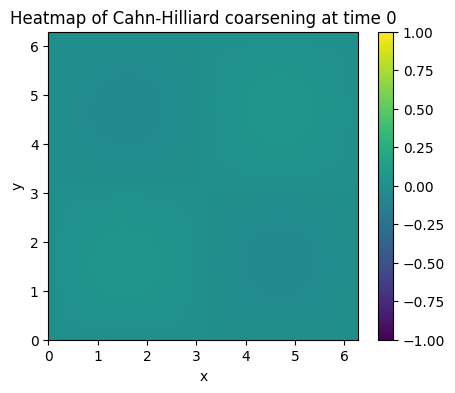

The max of u_total[-1] is 0.05
The min of u_total[-1] is -0.05


Solving:  91%|███████████████████████████████████████████████▎    | 10/11 [00:05<00:00,  1.84iter/s]

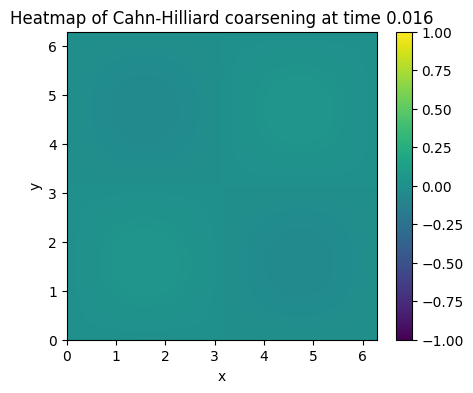

The max of u_total[-1] is 0.051579281722682446
The min of u_total[-1] is -0.05157928172268212


Solving: 100%|████████████████████████████████████████████████████| 11/11 [00:06<00:00,  1.75iter/s]


Final t is 0.016000000000000004


Solving:   0%|                                                             | 0/21 [00:00<?, ?iter/s]

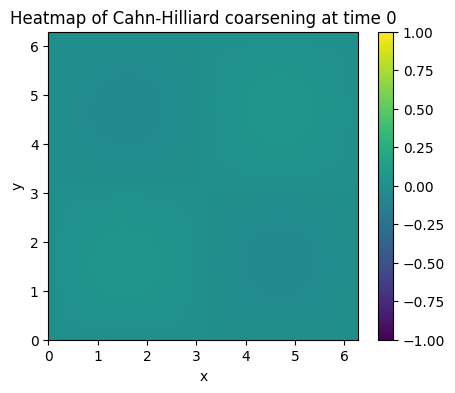

The max of u_total[-1] is 0.05
The min of u_total[-1] is -0.05


Solving:  95%|█████████████████████████████████████████████████▌  | 20/21 [00:11<00:00,  1.81iter/s]

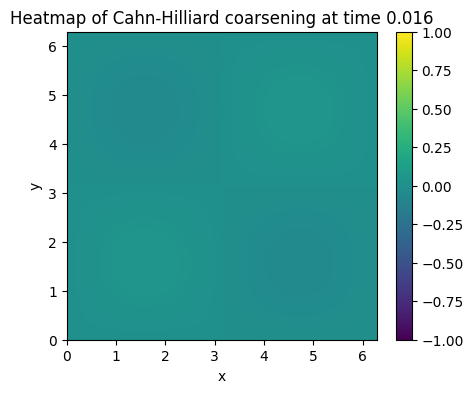

The max of u_total[-1] is 0.05157928202214526
The min of u_total[-1] is -0.051579282022145574


Solving: 100%|████████████████████████████████████████████████████| 21/21 [00:11<00:00,  1.76iter/s]


Final t is 0.016000000000000004


Solving:   0%|                                                             | 0/41 [00:00<?, ?iter/s]

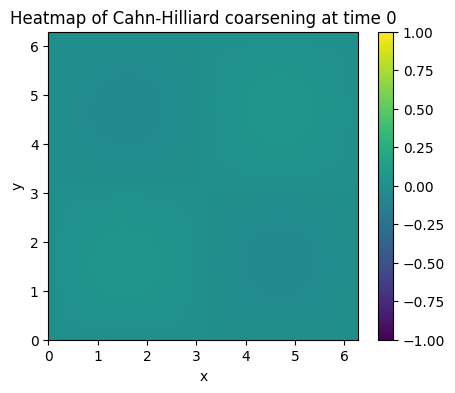

The max of u_total[-1] is 0.05
The min of u_total[-1] is -0.05


Solving:  98%|██████████████████████████████████████████████████▋ | 40/41 [00:24<00:00,  1.70iter/s]

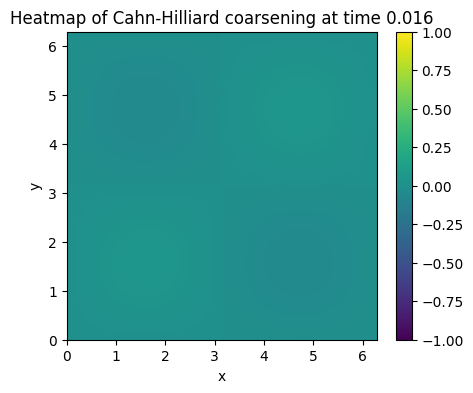

The max of u_total[-1] is 0.051579282096887925
The min of u_total[-1] is -0.05157928209688846


Solving: 100%|████████████████████████████████████████████████████| 41/41 [00:24<00:00,  1.64iter/s]


Final t is 0.01599999999999999


Solving:   0%|                                                             | 0/81 [00:00<?, ?iter/s]

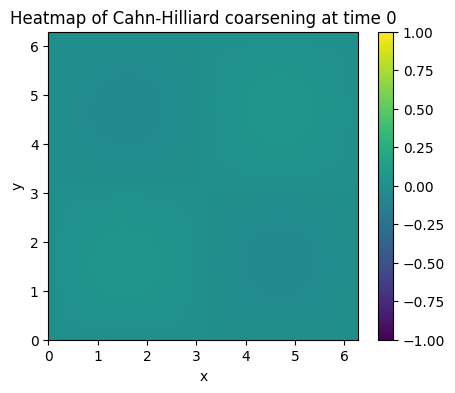

The max of u_total[-1] is 0.05
The min of u_total[-1] is -0.05


Solving:  99%|███████████████████████████████████████████████████▎| 80/81 [00:46<00:00,  1.70iter/s]

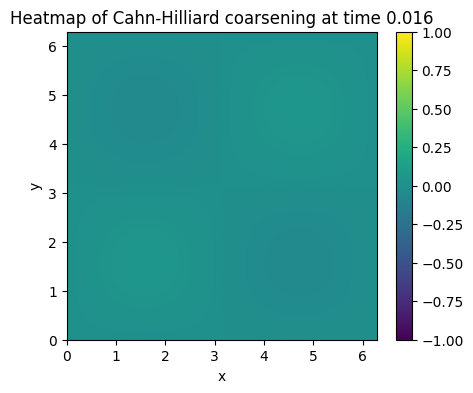

The max of u_total[-1] is 0.05157928211555949
The min of u_total[-1] is -0.05157928211555974


Solving: 100%|████████████████████████████████████████████████████| 81/81 [00:46<00:00,  1.73iter/s]


Final t is 0.016000000000000014


Solving:   0%|                                                            | 0/161 [00:00<?, ?iter/s]

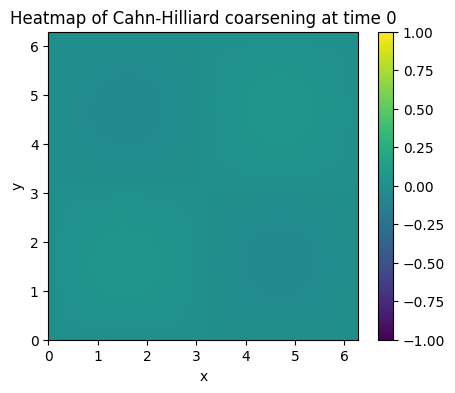

The max of u_total[-1] is 0.05
The min of u_total[-1] is -0.05


Solving:  62%|███████████████████████████████                   | 100/161 [00:57<00:36,  1.67iter/s]

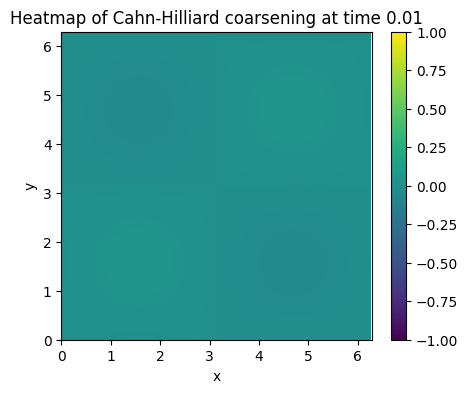

The max of u_total[-1] is 0.05098155343201022
The min of u_total[-1] is -0.05098155343201009


Solving:  99%|█████████████████████████████████████████████████▋| 160/161 [01:32<00:00,  1.80iter/s]

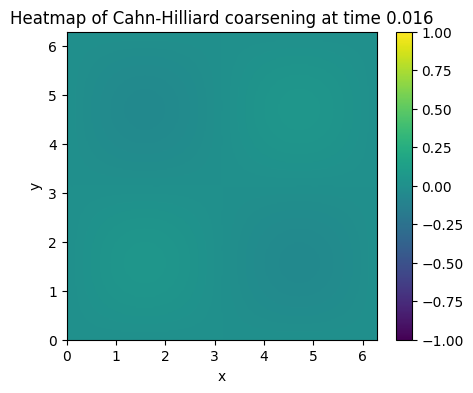

The max of u_total[-1] is 0.05157928212022431
The min of u_total[-1] is -0.051579282120223835


Solving: 100%|██████████████████████████████████████████████████| 161/161 [01:33<00:00,  1.73iter/s]


Final t is 0.01599999999999996


Solving:   0%|                                                            | 0/321 [00:00<?, ?iter/s]

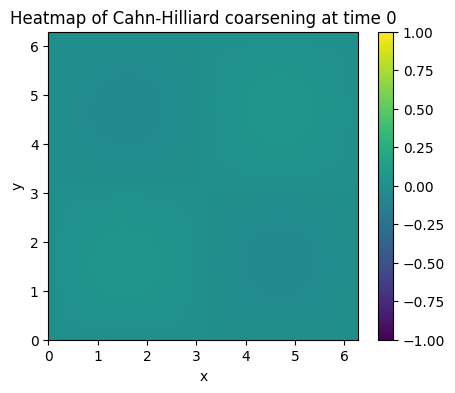

The max of u_total[-1] is 0.05
The min of u_total[-1] is -0.05


Solving:  31%|███████████████▌                                  | 100/321 [00:56<02:03,  1.78iter/s]

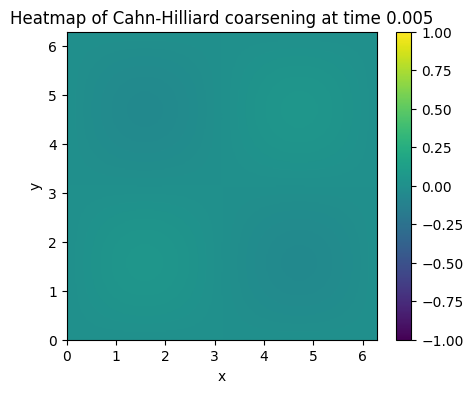

The max of u_total[-1] is 0.05048849690725724
The min of u_total[-1] is -0.0504884969072576


Solving:  62%|███████████████████████████████▏                  | 200/321 [01:55<01:09,  1.75iter/s]

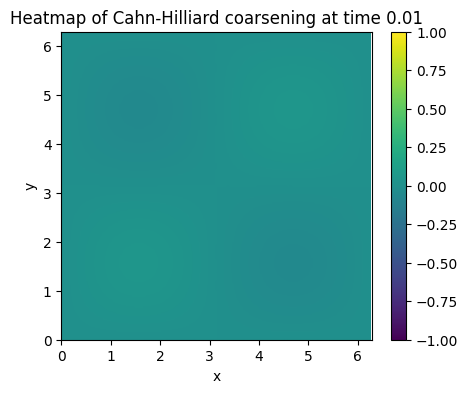

The max of u_total[-1] is 0.050981553432753055
The min of u_total[-1] is -0.050981553432755136


Solving:  93%|██████████████████████████████████████████████▋   | 300/321 [02:53<00:13,  1.59iter/s]

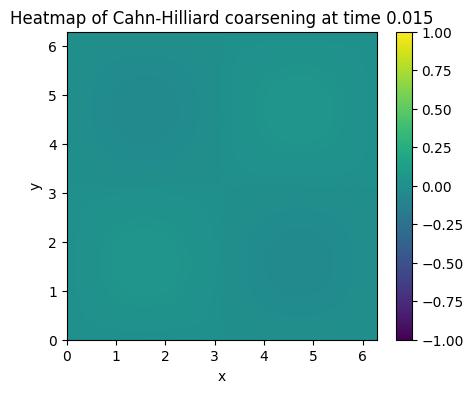

The max of u_total[-1] is 0.05147919954936642
The min of u_total[-1] is -0.051479199549367534


Solving: 100%|█████████████████████████████████████████████████▊| 320/321 [03:05<00:00,  1.67iter/s]

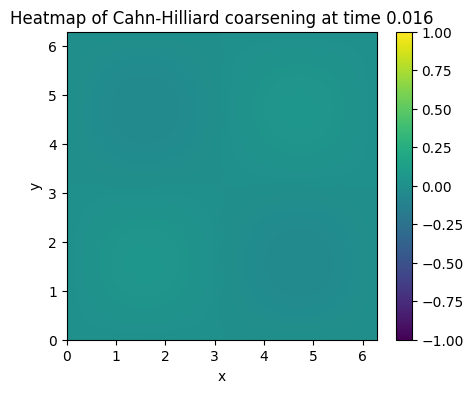

The max of u_total[-1] is 0.05157928212138826
The min of u_total[-1] is -0.051579282121389125


Solving: 100%|██████████████████████████████████████████████████| 321/321 [03:06<00:00,  1.72iter/s]

Final t is 0.015999999999999945


In [ ]:
'''
Test for the order of convergence
'''
test_num = 6

final_simulation = []

for i in range(test_num):
    # my_solver = solvers.Cahn_Hilliard_Solver_2D_Constant_Timestep("RKL2_2D_CH", s, Nx, Ny, dt/2**i, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=100)
    my_solver = solvers.Cahn_Hilliard_Solver_2D_Constant_Timestep("RKG2_2D_CH", s, Nx, Ny, dt/2**i, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=100)
    my_solver.initialize(display=False)

    my_solver.solve()
    u_total, t_total, energy_total, mesh_grid = my_solver.get_results()
    print("Final t is " + str(t_total[-2]))
    final_simulation.append(u_total[-2])

In [18]:
error_list = []
for i in range(test_num-1):
    test_vec = (final_simulation[i] - final_simulation[i+1]).reshape(-1)
    error_list.append(np.linalg.norm(test_vec, ord=2))

order_list = []
for i in range(len(error_list)-1):
    order_list.append(np.log(error_list[i]/error_list[i+1])/np.log(2))

print(error_list)
print(order_list)

[np.float64(6.404217990887675e-08), np.float64(1.6026905871358133e-08), np.float64(4.008764544015817e-09), np.float64(1.0023722807737257e-09), np.float64(2.50443987139924e-10)]
[np.float64(1.998526488077829), np.float64(1.9992663400279547), np.float64(1.9997392582748381), np.float64(2.000858544832863)]


In [19]:
error_list = []
for i in range(test_num-1):
    test_vec = (final_simulation[i] - final_simulation[i+1]).reshape(-1)
    error_list.append(np.linalg.norm(test_vec, ord=np.inf))

order_list = []
for i in range(len(error_list)-1):
    order_list.append(np.log(error_list[i]/error_list[i+1])/np.log(2))

print(error_list)
print(order_list)

[np.float64(3.9712595018004393e-10), np.float64(9.942349721292487e-11), np.float64(2.487560851749393e-11), np.float64(6.221724524468897e-12), np.float64(1.5577053535942298e-12)]
[np.float64(1.9979378808358705), np.float64(1.9988550329516765), np.float64(1.9993453938309154), np.float64(1.9978921514753873)]
